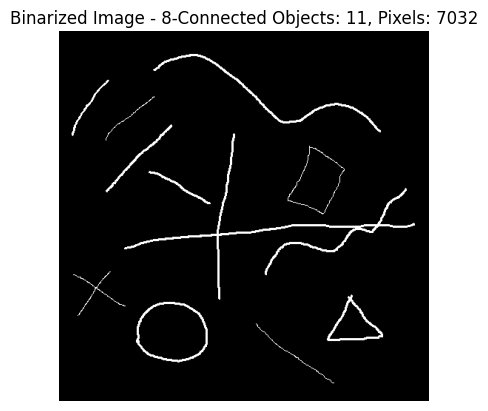

8-Connected Objects: 11
Total Object Pixels: 7032
Binarized Image - 8-Connected Objects: 11


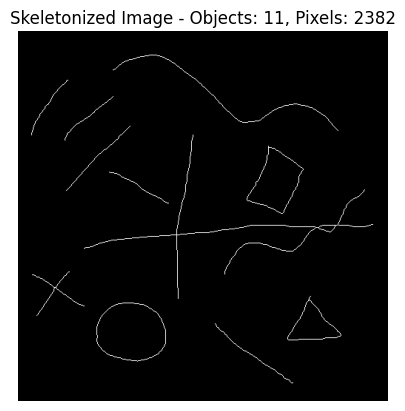

Skeletonized Objects: 11
Skeletonized Object Pixels: 2382


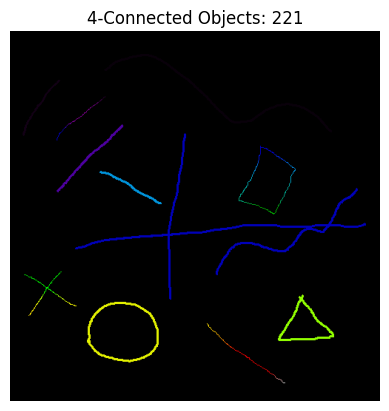

4-Connected Objects: 221


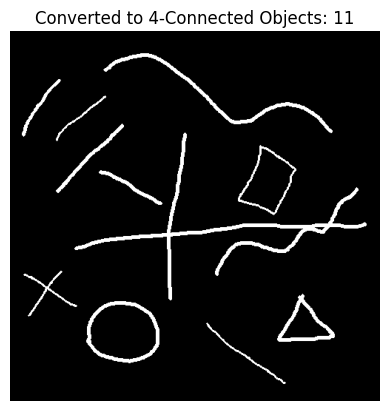

Converted 4-Connected Objects: 11
Total Object Pixels (converted): 11902


In [29]:
# Step 1: Load the image and count 8-connected objects and object pixels

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the input image
image_path = '/content/PracticalExamImage.bmp'  # Change to your image path
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply binary thresholding
_, binary_image = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Count connected components (8-connectivity)
num_labels_8, labels_8, stats_8, centroids_8 = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

# Count total number of object pixels
object_pixels_8 = np.sum(binary_image == 255)

# Display the binarized image
plt.imshow(binary_image, cmap='gray')
plt.title(f'Binarized Image - 8-Connected Objects: {num_labels_8 - 1}, Pixels: {object_pixels_8}')
plt.axis('off')
plt.show()

print("8-Connected Objects:", num_labels_8 - 1)
print("Total Object Pixels:", object_pixels_8)


# Step 2: Convert to binary and recount (8-connectivity)

# Count connected components after binarization using 8-connectivity
num_labels_bin_8, _, _, _ = cv2.connectedComponentsWithStats(binary_image, connectivity=8)

print("Binarized Image - 8-Connected Objects:", num_labels_bin_8 - 1)


# Step 3: Skeletonize the objects and recount

from skimage.morphology import skeletonize

# Convert binary image to boolean for skeletonization
binary_bool = binary_image > 0

# Perform skeletonization
skeleton = skeletonize(binary_bool)

# Count total number of skeletonized object pixels
skeleton_pixels = np.sum(skeleton)

# Count 8-connected components in skeletonized image
skeleton_uint8 = (skeleton * 255).astype(np.uint8)
num_labels_skel, _, _, _ = cv2.connectedComponentsWithStats(skeleton_uint8, connectivity=8)

# Display skeletonized image
plt.imshow(skeleton, cmap='gray')
plt.title(f'Skeletonized Image - Objects: {num_labels_skel - 1}, Pixels: {skeleton_pixels}')
plt.axis('off')
plt.show()

print("Skeletonized Objects:", num_labels_skel - 1)
print("Skeletonized Object Pixels:", skeleton_pixels)


# Step 4: Count objects using 4-connectivity

# Count connected components (4-connectivity)
num_labels_4, labels_4, stats_4, centroids_4 = cv2.connectedComponentsWithStats(binary_image, connectivity=4)

# Display the image with 4-connectivity result
plt.imshow(labels_4, cmap='nipy_spectral')
plt.title(f'4-Connected Objects: {num_labels_4 - 1}')
plt.axis('off')
plt.show()

print("4-Connected Objects:", num_labels_4 - 1)

# Step 5:

from scipy.ndimage import binary_dilation

# Convert 8-connected components to 4-connected with minimal extra pixels
kernel = np.array([[0, 1, 0],
                   [1, 1, 1],
                   [0, 1, 0]], dtype=np.uint8)  # 4-connectivity structuring element

four_connected = binary_dilation(binary_image, structure=kernel)

# Count connected components after conversion to 4-connectivity
four_connected_uint8 = four_connected.astype(np.uint8) * 255
num_labels_conv_4, _, _, _ = cv2.connectedComponentsWithStats(four_connected_uint8, connectivity=4)

# Display the modified 4-connected image
plt.imshow(four_connected, cmap='gray')
plt.title(f'Converted to 4-Connected Objects: {num_labels_conv_4 - 1}')
plt.axis('off')
plt.show()

print("Converted 4-Connected Objects:", num_labels_conv_4 - 1)
print("Total Object Pixels (converted):", np.sum(four_connected))